# Exhaustive Feature Selection 

## 1. What is a Wrapper Method?
Unlike **Filter Methods** (which look purely at the statistical properties of your features without training a model), **Wrapper Methods** treat feature selection as a search problem. 

A wrapper method uses a actual machine learning model (e.g., Logistic Regression, Random Forest) as an evaluation engine. It "wraps" the model around different combinations of features, trains the model on each combination, and evaluates performance using a validation metric (like R², Accuracy, or ROC-AUC). Features are selected based on how well the model actually performs when using them.


## 2. Exhaustive Feature Selection (EFS) Overview
**Exhaustive Feature Selection (EFS)** is the most brute-force, uncompromising wrapper method available. 

### Core Logic
EFS evaluates **every single possible combination** of features within a specified range. If you have a dataset with N features, it will evaluate all subsets of size 1, size 2, size 3, all the way up to size N. It guarantees finding the absolute best performing feature subset for your specific model because it leaves no stone unturned.

### Mathematical Formulation
The total number of feature combinations evaluated by an exhaustive search is calculated using the combinatorial binomial coefficient (combinations formula). 

If you search for all possible subset sizes from a minimum size $k_{\text{min}}$ to a maximum size $k_{\text{max}}$ out of a total pool of N features, the total number of models trained (M) is:

$$M = \sum_{k=k_{\text{min}}}^{k_{\text{max}}} \binom{N}{k} = \sum_{k=k_{\text{min}}}^{k_{\text{max}}} \frac{N!}{k!(N - k)!}$$

#### The Combinatorial Explosion (The Curse of EFS)
If you search for *every possible subset size* from 1 to N, the total number of combinations is:

$$M = 2^N - 1$$

*   If N = 5 features: $2^5 - 1 = \mathbf{31\text{ models}}$ (Blazing fast)
*   If N = 10 features: $2^{10} - 1 = \mathbf{1,023\text{ models}}$ (Takes a few seconds)
*   If N = 20 features: $2^{20} - 1 = \mathbf{1,048,575\text{ models}}$ (Takes hours)
*   If N = 30 features: $2^{30} - 1 = \mathbf{1,073,741,823\text{ models}}$ (Will crash or run for days)








In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, ConfusionMatrixDisplay
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.pipeline import Pipeline
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# A. Classification 

# 1. Load and Inspect Dataset

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

# Feature name
feature_names = iris.feature_names

df_iris = pd.DataFrame(X_iris, columns=feature_names)
df_iris['target'] = y_iris

print(f"Shape of the dataset: {df_iris.shape}")
df_iris.sample(5)

Shape of the dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
94,5.6,2.7,4.2,1.3,1
74,6.4,2.9,4.3,1.3,1
51,6.4,3.2,4.5,1.5,1
48,5.3,3.7,1.5,0.2,0
65,6.7,3.1,4.4,1.4,1


In [14]:
print(f"Shape of the dataset: {df_iris.shape}")

Shape of the dataset: (150, 5)


In [3]:
# check for Data type and null values
print(f"Number of rows with missing values: {df_iris.isnull().sum().sum()}")
df_iris.info()

Number of rows with missing values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
# target value
print(pd.Series(y_iris).value_counts().sort_index()) # Perfectly balanced dataset

0    50
1    50
2    50
Name: count, dtype: int64


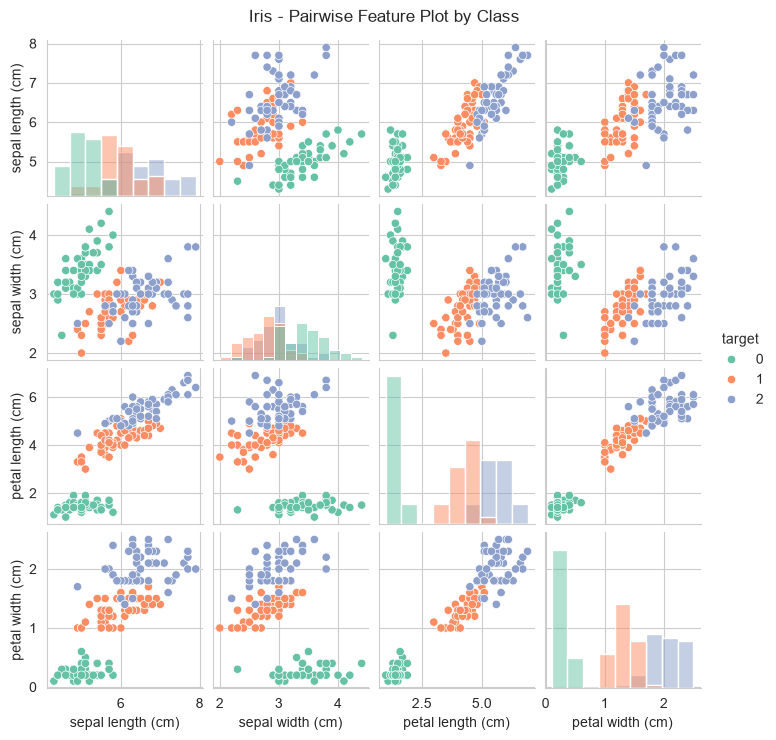

In [5]:
g = sns.pairplot(df_iris, hue="target", palette="Set2", diag_kind="hist", height=1.8)
g.fig.suptitle("Iris - Pairwise Feature Plot by Class", y=1.02)
plt.show()

**Observation:** even from this pairplot, `petal length`/`petal width` visibly separate the three classes far more cleanly than the two sepal
measurements do  worth remembering as a sanity check once the exhaustive search reports its verdict below.

# 2.  Baseline model (All  features)

A KNN classifier (k=5), features standardized first since KNN is a distance-based model and genuinely sensitive to feature scale.

In [6]:
def classifier(x,y):
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
    
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Pipeline for Standardization and KNN Classifier
    model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf",  KNeighborsClassifier(n_neighbors=5))
        ])

    # Classifier
    model.fit(X_train, y_train)

    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    cv_score = cross_val_score(KNeighborsClassifier(n_neighbors=5), x, y, cv=cv_strategy).mean()
    
    metric = {
        "n_features":X_train.shape[1],
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Cross-Validation Score": cv_score,
    }
    
    return metric


# 3. Pick Best Subset

In [15]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Selecting Best Features using Exhaustive Feature Selection
mlx_EFS_clf = EFS(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)), min_features=1, max_features=3, scoring='r2', cv=cv_strategy , print_progress=False)

# Fit the model with all features and evaluate performance
mlx_EFS_clf.fit(X_iris, y_iris)


# Extracting the best features
mlx_best_features = [feature_names[i] for i in mlx_EFS_clf.best_idx_]

# Selection Metric
print(f"MLXTEND Best Features : {mlx_best_features}")
print(f"Best R2 Score         : {mlx_EFS_clf.best_score_:.4f}")

MLXTEND Best Features : ['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Best R2 Score         : 0.9500


### 3.1 All the possible subsets 

In [16]:
# Get CV results for every evaluated feature subset
metric_dict_clf = mlx_EFS_clf.get_metric_dict() # Contains all the possible feature subsets and it's model performance

# Get useful data from metric_dict
subset_results_clf = []

for result in metric_dict_clf .values():
    subset_results_clf.append({
        "n_features": len(result["feature_idx"]),
        "cv_r2": result["avg_score"],
        "feature_idx": result["feature_idx"]   
    })

results_clf = pd.DataFrame(subset_results_clf)
results_clf # All subsets and their performance

,n_features,cv_r2,feature_idx
0,1,0.45,"(0,)"
1,1,-0.45,"(1,)"
2,1,0.92,"(2,)"
3,1,0.94,"(3,)"
4,2,0.62,"(0, 1)"
5,2,0.90,"(0, 2)"
6,2,0.94,"(0, 3)"
7,2,0.86,"(1, 2)"
8,2,0.92,"(1, 3)"
9,2,0.94,"(2, 3)"


### 3.2 Best Subset at Each Number of Features

In [17]:
# Best subset at each number of features
best_by_size = (results_clf.loc[
    results_clf.groupby("n_features")["cv_r2"].idxmax()].sort_values("n_features")
                )

best_by_size # Best subset for each feature count

,n_features,cv_r2,feature_idx
3,1,0.94,"(3,)"
6,2,0.94,"(0, 3)"
13,3,0.95,"(1, 2, 3)"


### 3.3 Number of of Features vs. CV R2 Score

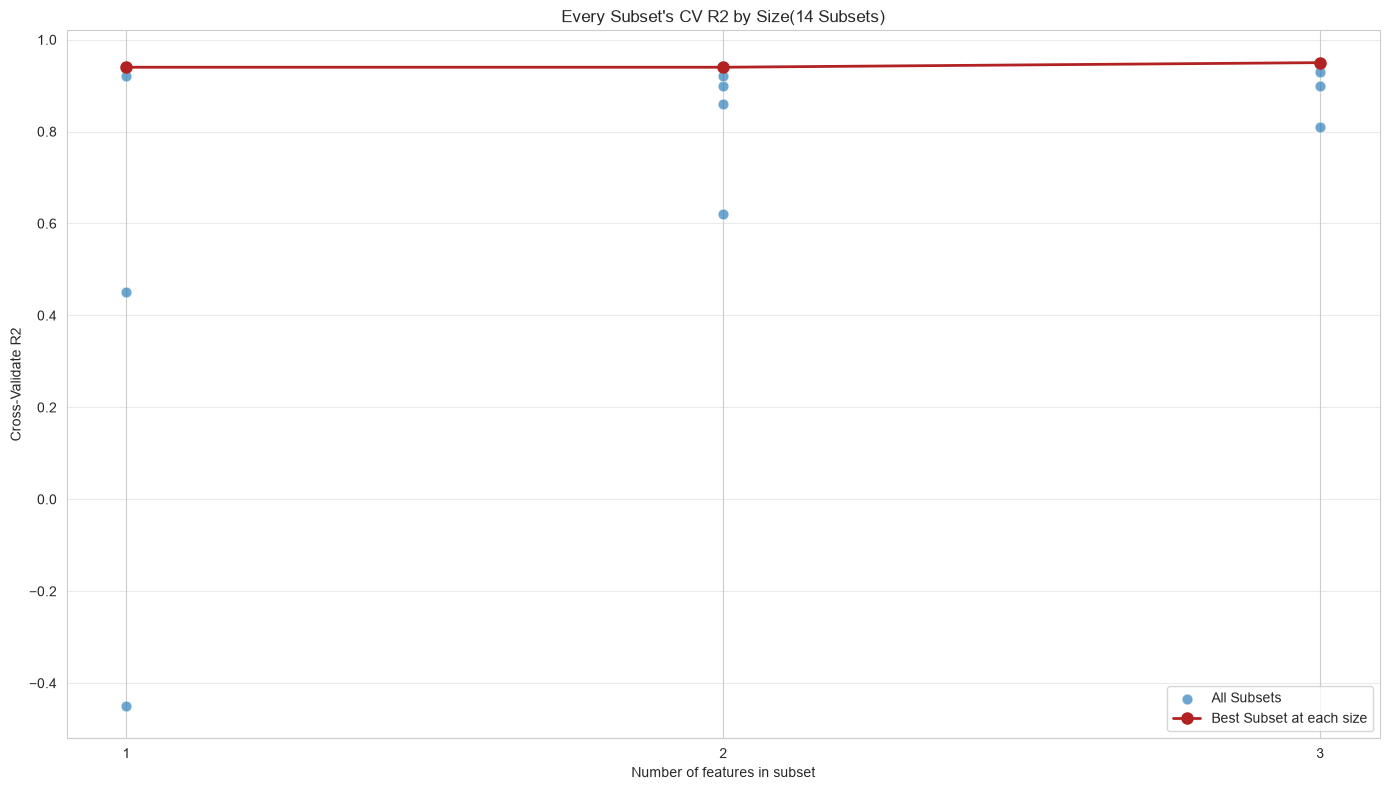

In [18]:
plt.figure(figsize=(14, 8))

# Plot every subset
sns.scatterplot(
    data=results_clf,
    x="n_features",
    y="cv_r2",
    alpha=0.65,
    s=60,
    label="All Subsets"
)

# Plot the best subset for each feature count
plt.plot(
    best_by_size["n_features"],
    best_by_size["cv_r2"],
    color="firebrick",
    marker="o",
    linewidth=2,
    markersize=8,
    label="Best Subset at each size"
)

plt.title(
    f"Every Subset's CV R2 by Size"
    f"({len(results_clf)} Subsets)"
)

plt.xlabel("Number of features in subset")
plt.ylabel("Cross-Validate R2")
plt.xticks(sorted(results_clf["n_features"].unique()))
plt.grid(axis="y", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

**observations** 
1. By Selecting All the Features model perform better than the model with only 3 features.
2. The difference between the best 3 and 4 feature models is quite small. If the data is in million less number of features can also yield a better model.


# 4. Model training and Evaluation

In [19]:
# Automatically get the best subset selected by EFS
best_idx_iris = list(mlx_EFS_clf.best_idx_)

# Convert indices to feature names
best_features_iris = [
    feature_names[i]
    for i in best_idx_iris
]

print("Selected features:", best_features_iris)
print("Number of selected features:", len(best_idx_iris))

# Baseline: all features
baseline_model = classifier(X_iris, y_iris)

# Selected subset: use NumPy column indices
selected_model = classifier(
    X_iris[:, best_idx_iris],
    y_iris
)

Selected features: ['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Number of selected features: 3


In [20]:
comparison = pd.DataFrame(
    [baseline_model, selected_model],
    index=[
        "Baseline",
        f"Selected ({len(best_features_iris)} features)"
    ]
)

comparison

,n_features,Train Accuracy,Test Accuracy,Cross-Validation Score
Baseline,4,0.975,0.933333,0.966667
Selected (3 features),3,0.975,0.966667,0.960000


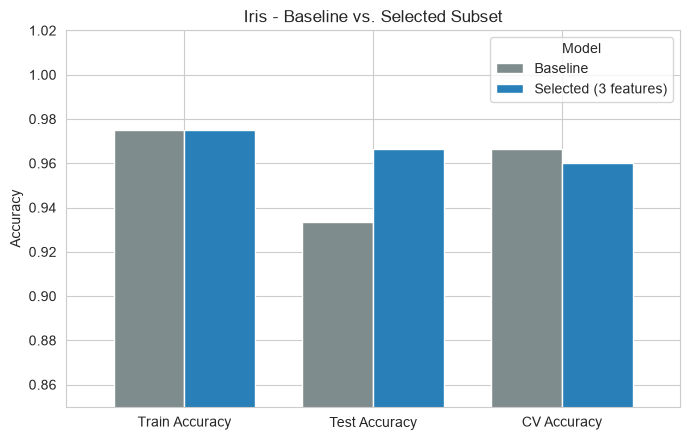

In [21]:
accuracy_comparison = comparison[
    ["Train Accuracy", "Test Accuracy", "Cross-Validation Score"]
]

ax = accuracy_comparison.T.plot(
    kind="bar",
    figsize=(7, 4.5),
    color=["#7f8c8d", "#2980b9"],
    width=0.75
)

ax.set_title("Iris - Baseline vs. Selected Subset")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.85, 1.02)
ax.set_xlabel("")
ax.set_xticklabels(
    ["Train Accuracy", "Test Accuracy", "CV Accuracy"],
    rotation=0
)
ax.legend(title="Model")

plt.tight_layout()
plt.show()

# B. Regression



# 1. Load Dataset and Inspect

In [113]:
df = pd.read_csv("../DataSets/concrete.csv")

x_reg = df.drop('Strength', axis=1)
y_reg = df['Strength']

df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
1017,313.8,0.0,112.6,169.9,10.1,925.3,782.9,28,38.46
420,165.0,128.5,132.1,175.1,8.1,1005.8,746.6,14,33.09
435,167.4,129.9,128.6,175.5,7.8,1006.3,746.6,28,41.20
58,304.0,76.0,0.0,228.0,0.0,932.0,670.0,180,50.95
819,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,90,58.78


8 numeric features (`Cement`, `Blast Furnace Slag`, `Fly Ash`, `Water`, `Superplasticizer`, `Coarse Aggregate`, `Fine Aggregate`, `Age`), target =`Strength`. 2⁸ - 1 = 255 subsets — still fast for linear regression, but big enough to actually show the R² vs. Adjusted R² distinction that Iris, with only 4 features, wouldn't have made obvious.

In [114]:
df.info() # NO Missing Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


# 2. Correlation 

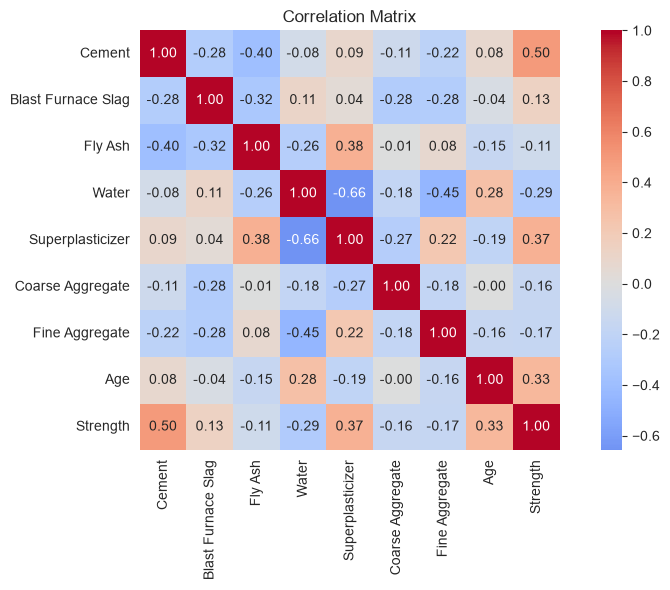

In [115]:
# Correlation Matrix
plt.figure(figsize=(9,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation:** `Cement` and `Age` show the strongest raw correlation with `Strength`; `Coarse Aggregate` and `Fine Aggregate` look weak on both `Strength` and most other features — worth remembering as a sanity check once the exhaustive search below reports its own verdict, independently of this simple pairwise view.

# 3. Regression Model

## 3.1 R² and Adjusted R² 

**R²** is the fraction of the target's variance the model accounts for 1.0 is a perfect fit, 0.0 is no better than always predicting the mean.

**Adjusted R²** answers a different question: R² can only go up (or stay flat) as more features are added, even features that are pure noise —
because a linear model with more parameters can always fit training data at least as well.

Adjusted R² corrects for this by penalizing the score based on how many predictors were used relative to the sample size, so it can actually *decrease* when an added feature isn't pulling its weight. That's what makes it the right metric for comparing models with different feature counts, rather than R² alone.

In [116]:
def adjusted_r2(r2, n_samples, n_features):
    return 1 - (1-r2) * (n_samples - 1) / (n_samples - n_features - 1)

## 3.2 Baseline Model

In [131]:
def regression(x,y):
    
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    model = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
    model.fit(X_train, y_train)

    # R2 Score 
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))

    # Adjusted R2 Score
    test_adjusted_r2 = adjusted_r2(test_r2, X_test.shape[0], X_test.shape[1])

    # Test RMS
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

    # cross Validation r2 score 
    cv_r2_scores = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()), x, y, cv=kf, scoring='r2')
    
    
    metric = {
        "Train R2 Score": train_r2,
        "Test R2 Score": test_r2,
        "Adjusted R2 Score": test_adjusted_r2,
        "Test RMSE": test_rmse,
        "Cross Validation R2 Scores": cv_r2_scores.mean(), 
    }
    
    return metric



# 4. Cross check against `mlxtend.ExhaustiveFeatureSelector`


In [144]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# Selecting Best Features using Exhaustive Feature Selection
mlx_EFS_reg = EFS(make_pipeline(StandardScaler(), LinearRegression()), min_features=1, max_features=5, scoring='r2', cv=kf, print_progress=False)

# Fit the model with all features and evaluate performance
mlx_EFS_reg.fit(x_reg, y_reg)

# Extracting the name of features
feature_name = df.columns[:-1].tolist()

# Extracting the best features
mlx_best_features = [feature_name[i] for i in mlx_EFS_reg.best_idx_]

# Selection Metric
print(f"MLXTEND Best Features : {mlx_best_features}")
print(f"Best R2 Score         : {mlx_EFS_reg.best_score_:.4f}")

MLXTEND Best Features : ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Age']
Best R2 Score         : 0.6000


### 4.1 Evaluation on each subsets

In [145]:
# Get CV results for every evaluated feature subset
metric_dict = mlx_EFS_reg.get_metric_dict() # Contains all the possible feature subsets and it's model performance

# Get useful data from metric_dict
subset_results = []

for result in metric_dict.values():
    subset_results.append({
        "n_features": len(result["feature_idx"]),
        "cv_r2": result["avg_score"],
        "feature_idx": result["feature_idx"],
        "feature_name" : result["feature_names"]    
    })

result_df = pd.DataFrame(subset_results)
result_df # All subsets and their performance

,n_features,cv_r2,feature_idx,feature_name
0,1,0.239528,"(0,)","(Cement,)"
1,1,0.011863,"(1,)","(Blast Furnace Slag,)"
2,1,0.003348,"(2,)","(Fly Ash,)"
3,1,0.082049,"(3,)","(Water,)"
4,1,0.131693,"(4,)","(Superplasticizer,)"
...,...,...,...,...
213,5,0.380260,"(2, 3, 4, 5, 7)","(Fly Ash, Water, Superplasticizer, Coarse Aggr..."
214,5,0.451714,"(2, 3, 4, 6, 7)","(Fly Ash, Water, Superplasticizer, Fine Aggreg..."
215,5,0.516063,"(2, 3, 5, 6, 7)","(Fly Ash, Water, Coarse Aggregate, Fine Aggreg..."
216,5,0.389343,"(2, 4, 5, 6, 7)","(Fly Ash, Superplasticizer, Coarse Aggregate, ..."


### 4.2 Pick best from each subsets

In [146]:
# Best subset at each number of features
best_by_size = (result_df.loc[
    result_df.groupby("n_features")["cv_r2"].idxmax()].sort_values("n_features")
                )

best_by_size # Best subset for each feature count

,n_features,cv_r2,feature_idx,feature_name
0,1,0.239528,"(0,)","(Cement,)"
11,2,0.342795,"(0, 4)","(Cement, Superplasticizer)"
53,3,0.478132,"(0, 4, 7)","(Cement, Superplasticizer, Age)"
100,4,0.549179,"(0, 1, 3, 7)","(Cement, Blast Furnace Slag, Water, Age)"
165,5,0.599971,"(0, 1, 2, 3, 7)","(Cement, Blast Furnace Slag, Fly Ash, Water, Age)"


# 5. Number of features vs CV R2 Score

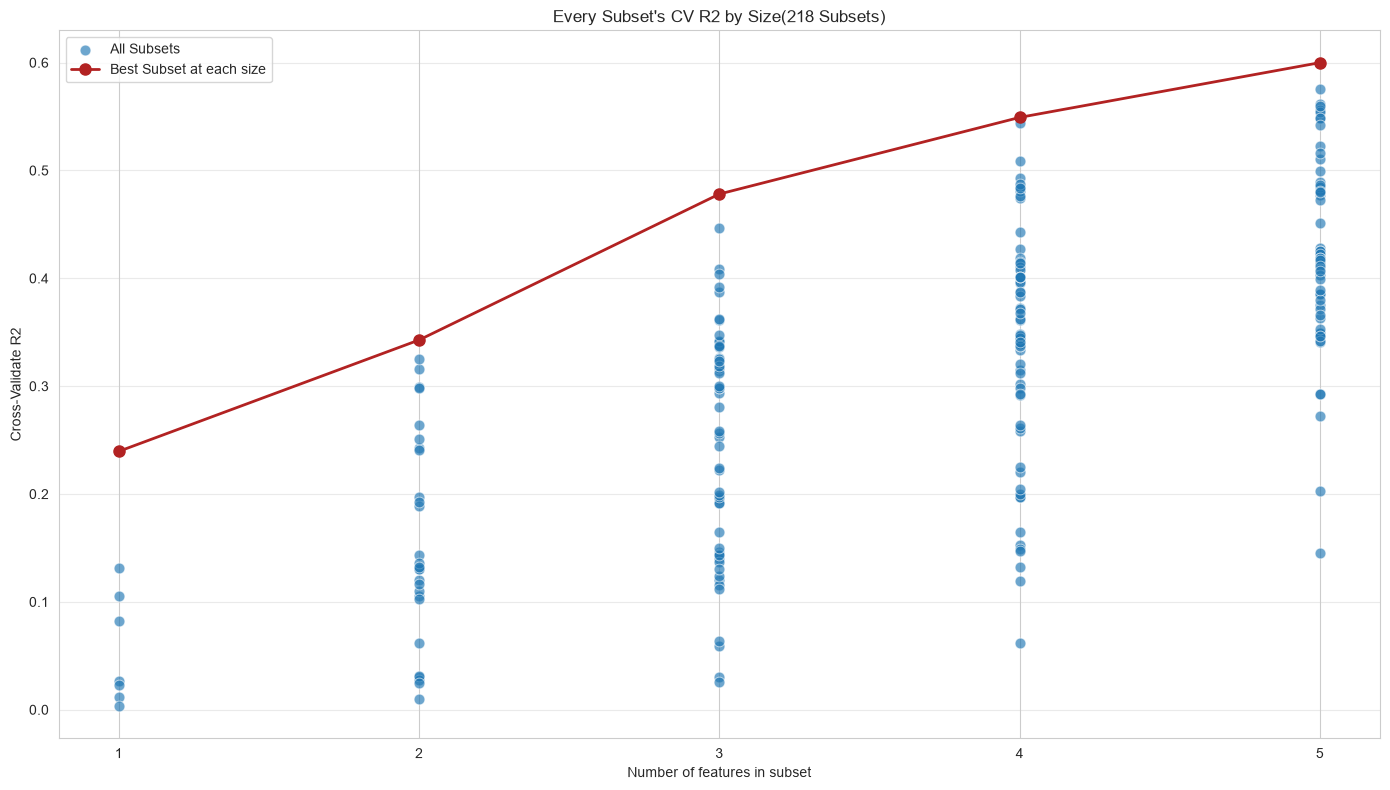

In [161]:

plt.figure(figsize=(14, 8))

# Plot every subset
sns.scatterplot(
    data=result_df,
    x="n_features",
    y="cv_r2",
    alpha=0.65,
    s=60,
    label="All Subsets"
)

# Plot the best subset for each feature count
plt.plot(
    best_by_size["n_features"],
    best_by_size["cv_r2"],
    color="firebrick",
    marker="o",
    linewidth=2,
    markersize=8,
    label="Best Subset at each size"
)

plt.title(
    f"Every Subset's CV R2 by Size"
    f"({len(result_df)} Subsets)"
)

plt.xlabel("Number of features in subset")
plt.ylabel("Cross-Validate R2")
plt.xticks(sorted(result_df["n_features"].unique()))
plt.grid(axis="y", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [149]:
# Automatically get the best subset selected by EFS
best_idx = list(mlx_EFS_reg.best_idx_)

# Convert indices to feature names
best_features = [
    feature_name[i]
    for i in best_idx
]

print("Selected features:", best_features)
print("Number of selected features:", len(best_idx))

# Baseline: all features
baseline_model = regression(x_reg, y_reg)

# Selected subset: use NumPy column indices
selected_model = regression(
    x_reg[best_features],
    y_reg
)

Selected features: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Age']
Number of selected features: 5


In [153]:
comparison = pd.DataFrame(
    [baseline_model, selected_model],
    index=[
        f"Baseline ({x_reg.shape[1]} features)",
        f"Selected ({len(best_features)} features)"
    ]
)

comparison

,Train R2 Score,Test R2 Score,Adjusted R2 Score,Test RMSE,Cross Validation R2 Scores
Baseline (8 features),0.610524,0.627553,0.612428,9.796476,0.600696
Selected (5 features),0.604512,0.630145,0.620898,9.762336,0.599971


# 6. Model Evaluation Before and After Feature Selection

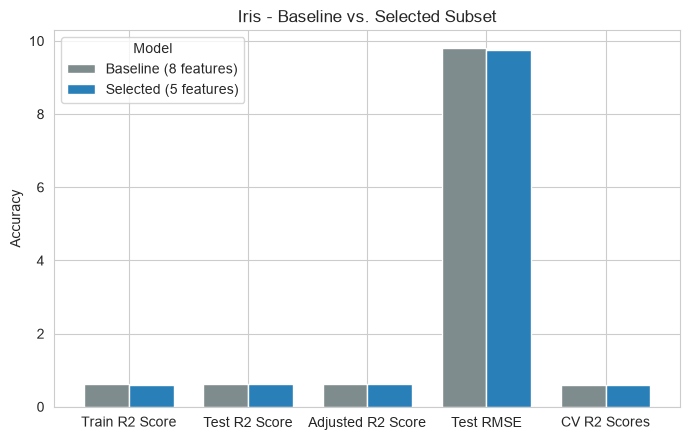

In [159]:
accuracy_comparison = comparison[
    ["Train R2 Score", "Test R2 Score", "Adjusted R2 Score", "Test RMSE", "Cross Validation R2 Scores"]
]

ax = accuracy_comparison.T.plot(
    kind="bar",
    figsize=(7, 4.5),
    color=["#7f8c8d", "#2980b9"],
    width=0.75
)

ax.set_title("Iris - Baseline vs. Selected Subset")
ax.set_ylabel("Accuracy")

ax.set_xlabel("")
ax.set_xticklabels(
    ["Train R2 Score", "Test R2 Score", "Adjusted R2 Score", "Test RMSE", "CV R2 Scores"],
    rotation=0
)
ax.legend(title="Model")

plt.tight_layout()
plt.show()

## 7. Strategic Decision Framework: When to Use vs. When to Avoid

### When to Use
*   **Low-Dimensional Datasets (N ≤ 15):** When your feature space is small enough that computing all combinations takes minutes or seconds.

*   **Safety-Critical Frameworks:** In medical diagnostics or aerospace applications where finding the absolute mathematical best subset of features justifies heavy computational costs.

*   **Feature Interaction Detection:** When you suspect that features only work well when paired together in highly specific combinations that single-variable filters completely miss.

### When to Avoid
*   **High-Dimensional Datasets (N > 20):** The exponential growth makes it computationally impossible unless you strictly restrict $k_{\text{max}}$ to a very small number (like 2 or 3).

*   **Slow-Training Target Models:** If your wrapper model is slow to train (like a deep neural network or a massive random forest), multiplying its training time by thousands of combinations will break your pipeline.




## 8. Model Sensitivities: Which Algorithms Matter Here?

Because EFS evaluates performance based on actual model outputs, the chosen "wrapper" model completely dictates the features selected.

### Complex, High-Variance Models (Decision Trees, Unregularized Linear Models)

*   **Impact:** **High risk of Overfitting.** If you run EFS using a basic Decision Tree without cross-validation, EFS will eagerly select a massive combination of features that perfectly overfits your training noise.

*   **Pipeline Fix:** You **must always use Cross-Validation (e.g., 5-Fold CV)** inside the EFS loop to ensure features are selected based on generalized validation scores, not training scores.

### Highly Regularized Models (Ridge, Lasso, ElasticNet)

*   **Impact:** **Redundant Asset.** Using EFS on top of a Lasso regression is often unnecessary because Lasso naturally performs feature selection internally by shrinking weights to zero.



## 9. Comprehensive Advantages & Disadvantages

### Advantages
*   **Guaranteed Global Optimum:** Unlike greedy search wrapper methods (like Forward Selection or Backward Elimination), EFS will never get stuck in local optima. It is mathematically guaranteed to find the absolute best combination.

*   **Captures Complex Interactions:** It easily identifies synergy between variables (e.g., Feature A and Feature B are useless alone, but when combined, they yield 95% accuracy).

*   **Model Agnostic:** You can use any Scikit-Learn estimator as your wrapper engine.

### Disadvantages
*   **Extreme Computational Cost:** Scalability is terrible due to exponential time complexity $\mathcal{O}(2^N)$.

*   **High Risk of Overfitting:** Evaluating thousands of combinations increases the probability that a random combination of features will perform exceptionally well purely by luck on your validation split.

